**Pré-Processamento - Lista 9**

In [ ]:
!pip -q install plotly --upgrade

**Importando bibliotecas**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

**Abrindo um arquivo CSV do drive**

In [ ]:
import pickle
base = pd.read_pickle('/content/sample_data/creditcard_tratado.pkl')

**Normalizar**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
base = scaler.fit_transform(base)

**Algoritmos de agrupamento**

**1) Kmeans**

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 2, random_state = 42, n_init='auto')
kmeans.fit(base)

KMeans(n_clusters=2, random_state=42)

In [ ]:
# Analisar Silhouette

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_score(base, kmeans.labels_, metric='euclidean')

np.float64(0.4901048484723746)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


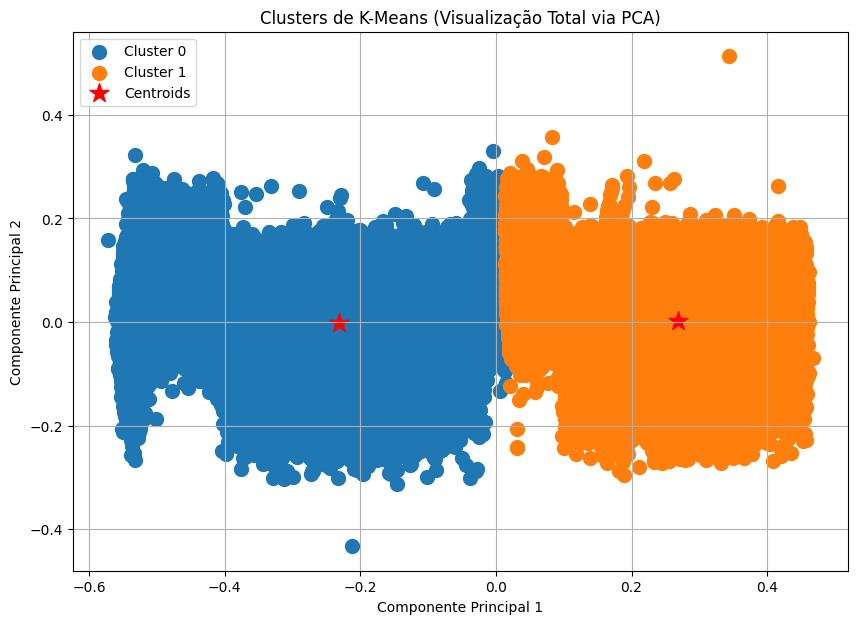

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(base)

# Obter os Centroids
clusters = kmeans.labels_
centroids = kmeans.cluster_centers_

# Transformar os Centroids para o espaço PCA
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(10, 7))

# Plotando cada cluster
for i in np.unique(clusters):
    plt.scatter(componentes_principais[clusters == i, 0],
                componentes_principais[clusters == i, 1],
                s = 100,
                label = f'Cluster {i}')

# Plotando os Centroids no espaço PCA
plt.scatter(centroids_pca[:, 0],
            centroids_pca[:, 1],
            s = 200,
            c = 'red',
            marker='*',
            label = 'Centroids')

plt.title('Clusters de K-Means (Visualização Total via PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.show()

**2) DBScan**

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(base)
clusters_dbscan = dbscan.fit_predict(base)

mask = dbscan_labels != -1
if sum(mask) > 0:
    dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
else:
    dbscan_silhouette = -1

print(f"Silhueta DBSCAN: {dbscan_silhouette:.4f}")
print(f"Clusters encontrados: {len(set(dbscan_labels))}")
print(f"Pontos considerados ruído: {sum(dbscan_labels == -1)}")

In [ ]:
df_plot_dbscan = pd.DataFrame(base, columns=[f'V{i}' for i in range(base.shape[1])])
df_plot_dbscan['Cluster'] = clusters_dbscan

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_plot_dbscan['V1'],
                      df_plot_dbscan['V0'],
                      c=df_plot_dbscan['Cluster'],
                      cmap='viridis',
                      alpha=0.7)

plt.colorbar(scatter, ticks=range(min(clusters_dbscan), max(clusters_dbscan) + 1))
plt.title('Resultados do Agrupamento DBSCAN (V1 vs V0)')
plt.xlabel('V1 (simulando V17)')
plt.ylabel('V0 (simulando V14)')
plt.grid(True, alpha=0.3)
plt.savefig('dbscan_v1_v0.png', dpi=300, bbox_inches='tight')
plt.show()


 **3) SOM**

In [ ]:
from minisom import MiniSom

In [ ]:
# tamanho da grade (m x n) e numero de features
GRID_SIZE_X = 8
GRID_SIZE_Y = 8
INPUT_DIM = base.shape[1]

som = MiniSom(GRID_SIZE_X, GRID_SIZE_Y, INPUT_DIM, sigma=0.5, learning_rate=0.3, random_seed=42)

# Inicializa os pesos do SOM
som.random_weights_init(base.values)

# Treina o SOM
som.train_random(base.values, num_iteration=100)

In [ ]:
som_labels = []
for x in base:
    winner = som.winner(x)
    cluster_id = winner[0] * GRID_SIZE_Y + winner[1]
    som_labels.append(cluster_id)

som_labels = np.array(som_labels)
som_silhouette = silhouette_score(base, som_labels)

print(f"=== SILHUETA SOM (Método Simples) ===")
print(f"Clusters únicos: {len(np.unique(som_labels))}")
print(f"Silhueta: {som_silhouette:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# Cria o mapa de distância (U-Matrix)
plt.figure(figsize=(8, 8))
# plota o mapa de distância: A cor representa a distância entre os neurônios vizinhos
plt.pcolor(som.distance_map().T, cmap='gist_yarg')
# mostra a barra de cores
cbar = plt.colorbar()
cbar.set_label('Distância Média entre Neurônios Vizinhos')
plt.title('Mapa de Distância do SOM (U-Matrix)')
plt.show()

**Comparando...**

In [ ]:
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(X_data, kmeans_labels)
score_dbscan = silhouette_score(X_data, dbscan_labels)

score_som_adapted = silhouette_score(X_data, som_labels)

print(f"Silhouette Score K-Means: {score_kmeans:.4f}")
print(f"Silhouette Score DBSCAN: {score_dbscan:.4f} (Note: -1 é ruído)")
print(f"Silhouette Score SOM (Adaptado): {score_som_adapted:.4f}")